In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("../data/raw/satellites_202602.csv")
df.sample(10)

,INTLDES,NORAD_CAT_ID,OBJECT_TYPE,SATNAME,COUNTRY,LAUNCH,SITE,DECAY,PERIOD,INCLINATION,...,FILE,LAUNCH_YEAR,LAUNCH_NUM,LAUNCH_PIECE,CURRENT,OBJECT_NAME,OBJECT_ID,OBJECT_NUMBER,ACTIVE,PURPOSE
53502,2024-140GC,60801,DEBRIS,CZ-6A DEB,PRC,2024-08-06,TSC,NaN,97.63,88.92,...,9413,2024,140,GC,Y,CZ-6A DEB,2024-140GC,60801,No,NaN
10189,1976-120G,11181,DEBRIS,COSMOS 880 DEB,CIS,1976-12-09,PKMTR,1979-07-20,91.85,65.80,...,1,1976,120,G,Y,COSMOS 880 DEB,1976-120G,11181,No,NaN
25612,1993-036CN,33845,DEBRIS,COSMOS 2251 DEB,CIS,1993-06-16,PKMTR,2022-10-12,90.32,74.01,...,9248,1993,36,CN,Y,COSMOS 2251 DEB,1993-036CN,33845,No,NaN
20369,1987-039D,18001,DEBRIS,COSMOS 1843 DEB,CIS,1987-05-05,TTMTR,1987-08-27,89.01,70.35,...,7870,1987,39,D,Y,COSMOS 1843 DEB,1987-039D,18001,No,NaN
59694,2026-018E,67593,PAYLOAD,STARLINK-36634,US,2026-01-29,AFWTR,NaN,91.41,97.28,...,9413,2026,18,E,Y,STARLINK-36634,2026-018E,67593,Yes,Communications
24386,1993-016W,22612,DEBRIS,SL-16 DEB,CIS,1993-03-26,TTMTR,NaN,99.86,70.97,...,9412,1993,16,W,Y,SL-16 DEB,1993-016W,22612,No,NaN
42907,2020-025N,45543,PAYLOAD,STARLINK-1372,US,2020-04-22,AFETR,NaN,94.11,53.16,...,9412,2020,25,N,Y,STARLINK-1372,2020-025N,45543,Yes,Communications
14470,1982-038L,14273,DEBRIS,COSMOS 1355 DEB,CIS,1982-04-29,TTMTR,1983-08-20,88.14,65.04,...,1,1982,38,L,Y,COSMOS 1355 DEB,1982-038L,14273,No,NaN
50282,2023-079K,56832,PAYLOAD,STARLINK-30128,US,2023-06-04,AFETR,NaN,95.84,43.00,...,9411,2023,79,K,Y,STARLINK-30128,2023-079K,56832,Yes,Communications
47270,2022-099H,53472,PAYLOAD,STARLINK-4447,US,2022-08-12,AFWTR,NaN,95.92,97.60,...,9380,2022,99,H,Y,STARLINK-4447,2022-099H,53472,Yes,Communications


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59997 entries, 0 to 59996
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   INTLDES        59997 non-null  str    
 1   NORAD_CAT_ID   59997 non-null  int64  
 2   OBJECT_TYPE    59997 non-null  str    
 3   SATNAME        59997 non-null  str    
 4   COUNTRY        59997 non-null  str    
 5   LAUNCH         59997 non-null  str    
 6   SITE           59997 non-null  str    
 7   DECAY          29940 non-null  str    
 8   PERIOD         59236 non-null  float64
 9   INCLINATION    59236 non-null  float64
 10  APOGEE         59236 non-null  float64
 11  PERIGEE        59236 non-null  float64
 12  COMMENT        745 non-null    str    
 13  COMMENTCODE    4085 non-null   float64
 14  RCSVALUE       59997 non-null  int64  
 15  RCS_SIZE       49289 non-null  str    
 16  FILE           59997 non-null  int64  
 17  LAUNCH_YEAR    59997 non-null  int64  
 18  LAUNCH_NUM     59

In [14]:
df["PURPOSE"].value_counts(dropna=False)

PURPOSE
NaN                       35740
Communications            12075
Technology Development    11022
Earth Observation          1160
Name: count, dtype: int64

In [15]:
df["OBJECT_TYPE"].value_counts()

OBJECT_TYPE
DEBRIS     35740
PAYLOAD    24257
Name: count, dtype: int64

In [16]:
df["LAUNCH"] = pd.to_datetime(df["LAUNCH"], errors="coerce")

df_sat = df[df["OBJECT_TYPE"] == "PAYLOAD"]
df_sat["YEAR"] = df_sat["LAUNCH"].dt.year

year_counts = df_sat.groupby("YEAR").size().sort_index()

counts = year_counts.cumsum()

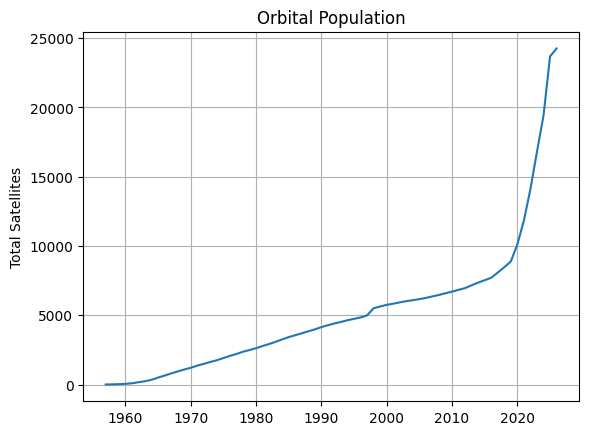

In [17]:
plt.figure()
plt.plot(counts.index, counts.values)

plt.ylabel("Total Satellites")
plt.title("Orbital Population")

plt.grid(True)
plt.show()